In [25]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
C:\Users\bartik\AppData\Local\Temp\ipykernel_22028\2467916011.py:31: SyntaxWarning: invalid escape sequence '\l'
  label=f'Minimum: $\lambda^*={lambda_star:.2f}, MFPT={mfpt_star:.2f}$')
C:\Users\bartik\AppData\Local\Temp\ipykernel_22028\2467916011.py:39: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)


Theoretical Optimal Resetting Rate (lambda*): 2.5396
Theoretical Minimum MFPT: 1.5441


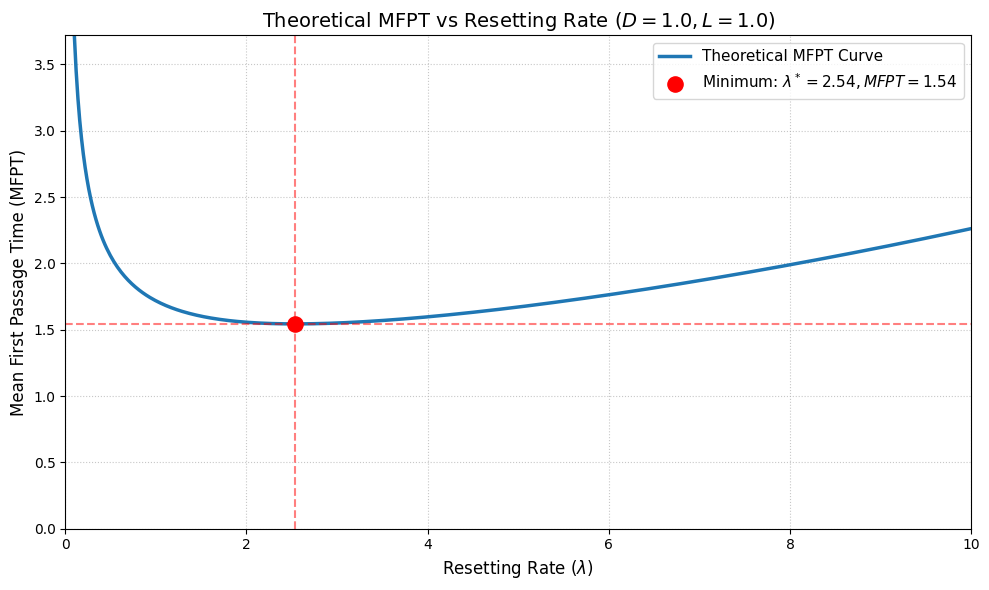

In [26]:
# --- 1. Set System Parameters ---
D = 1.0  # Diffusion coefficient
L = 1.0  # Distance to the absorbing target

# --- 2. Define the Theoretical MFPT Function ---
def theoretical_mfpt(lam, D, L):
    """Calculates the theoretical MFPT for a given lambda."""
    # We use np.where to handle lambda = 0 safely if it's in the array, 
    # though mathematically it approaches infinity.
    return np.where(lam == 0, np.inf, (1 / lam) * (np.exp(np.sqrt(lam / D) * L) - 1))
z = 1.593624 
lambda_star = D * (z / L)**2
mfpt_star = theoretical_mfpt(lambda_star, D, L)

print(f"Theoretical Optimal Resetting Rate (lambda*): {lambda_star:.4f}")
print(f"Theoretical Minimum MFPT: {mfpt_star:.4f}")

# --- 4. Generate Data for the Curve ---
# Create an array of lambda values from 0.1 up to 10
lambda_vals = np.linspace(0.1, 10.0, 500)
mfpt_vals = theoretical_mfpt(lambda_vals, D, L)

# --- 5. Plotting ---
plt.figure(figsize=(10, 6))

# Plot the main U-shaped curve
plt.plot(lambda_vals, mfpt_vals, color='#1f77b4', linewidth=2.5, label='Theoretical MFPT Curve')

# Highlight the optimal minimum point
plt.scatter(lambda_star, mfpt_star, color='red', s=120, zorder=5, 
            label=f'Minimum: $\lambda^*={lambda_star:.2f}, MFPT={mfpt_star:.2f}$')

# Add dashed guide lines to the axes for clarity
plt.axvline(x=lambda_star, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=mfpt_star, color='red', linestyle='--', alpha=0.5)

# Formatting
plt.title(f'Theoretical MFPT vs Resetting Rate ($D={D}, L={L}$)', fontsize=14)
plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)
plt.ylabel('Mean First Passage Time (MFPT)', fontsize=12)
plt.ylim(0, max(mfpt_vals[0], mfpt_vals[-1])) # Keep the y-axis bounded nicely
plt.xlim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

# Show the plot
plt.show()

<>:72: SyntaxWarning: invalid escape sequence '\l'
<>:72: SyntaxWarning: invalid escape sequence '\l'
C:\Users\bartik\AppData\Local\Temp\ipykernel_22028\4139309357.py:72: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)


Starting simulation for 20 points. Please wait...
Completed: 100% (20/20 points)
Simulation complete!
------------------------------
SIMULATION QUALITY METRICS
MAPE: 3.1267%
RMSE: 0.061215
------------------------------
Plot saved: plots/simulation_vs_theory.png


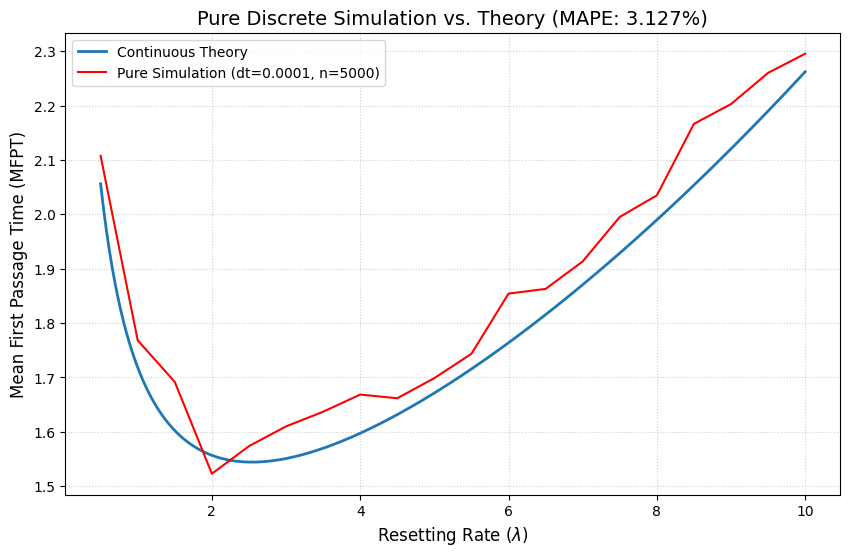

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# --- 1. Set System Parameters ---
D = 1.0
L = 1.0
dt = 1e-4
num_trials = 5000

@njit
def simulate_mfpt_pure(lam, D, L, dt, trials):
    if lam <= 0: 
        return np.nan
    
    total_fpt = 0.0
    sqrt_2Ddt = np.sqrt(2 * D * dt)
    p_reset = 1.0 - np.exp(-lam * dt) 
    
    for _ in range(trials):
        x = 0.0
        t = 0.0
        while x < L:
            if np.random.random() < p_reset:
                x = 0.0
            else:
                x += np.random.normal(0, 1.0) * sqrt_2Ddt
            t += dt
            if t > 500: 
                break
        total_fpt += t
        
    return total_fpt / trials

# --- 2. Generate Comparison Data ---
sim_lambda_vals = np.linspace(0.5, 10, 20)
total_points = len(sim_lambda_vals)
print(f"Starting simulation for {total_points} points. Please wait...")

sim_results = np.zeros(total_points)

for i, l in enumerate(sim_lambda_vals):
    sim_results[i] = simulate_mfpt_pure(l, D, L, dt, num_trials)
    percent = ((i + 1) / total_points) * 100
    print(f"\rCompleted: {percent:.0f}% ({i + 1}/{total_points} points)", end="", flush=True)

print("\nSimulation complete!")

theory_at_sim = (1 / sim_lambda_vals) * (np.exp(np.sqrt(sim_lambda_vals / D) * L) - 1)

# --- 3. Calculate Error Metrics ---
mape = np.mean(np.abs((theory_at_sim - sim_results) / theory_at_sim)) * 100
rmse = np.sqrt(np.mean((theory_at_sim - sim_results)**2))

print("-" * 30)
print(f"SIMULATION QUALITY METRICS")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.6f}")
print("-" * 30)

# --- 4. Plotting ---
plt.figure(figsize=(10, 6))
lam_theory_fine = np.linspace(0.5, 10, 500)
mfpt_theory_fine = (1 / lam_theory_fine) * (np.exp(np.sqrt(lam_theory_fine / D) * L) - 1)

plt.plot(lam_theory_fine, mfpt_theory_fine, label='Continuous Theory', color='#1f77b4', lw=2)
plt.plot(sim_lambda_vals, sim_results, color='red', 
            label=f'Pure Simulation (dt={dt}, n={num_trials})')

plt.title(f'Pure Discrete Simulation vs. Theory (MAPE: {mape:.3f}%)', fontsize=14)
plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)
plt.ylabel('Mean First Passage Time (MFPT)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# --- 5. Save Plot ---
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/simulation_vs_theory.png', dpi=300, bbox_inches='tight')
print("Plot saved: plots/simulation_vs_theory.png")

plt.show()

In [28]:
min_idx = np.argmin(sim_results)
lambda_opt_sim = sim_lambda_vals[min_idx]
min_mfpt_sim = sim_results[min_idx]

print(f"Numeryczne optimum lambda: {lambda_opt_sim:.3f} (MFPT = {min_mfpt_sim:.3f})")

Numeryczne optimum lambda: 2.000 (MFPT = 1.523)


In [29]:
from scipy.optimize import minimize_scalar

# Funkcja teoretyczna zdefiniowana dla optymalizatora
def theory_mfpt_scalar(lam, D=1.0, L=1.0):
    return (1 / lam) * (np.exp(np.sqrt(lam / D) * L) - 1)

# Szukamy minimum w przedziale od 0.1 do 10
res = minimize_scalar(theory_mfpt_scalar, bounds=(0.1, 10), method='bounded')
lambda_opt_theory = res.x
min_mfpt_theory = res.fun

print(f"Teoretyczne optimum lambda: {lambda_opt_theory:.4f} (MFPT = {min_mfpt_theory:.4f})")

Teoretyczne optimum lambda: 2.5396 (MFPT = 1.5441)


<>:87: SyntaxWarning: invalid escape sequence '\l'
<>:87: SyntaxWarning: invalid escape sequence '\l'
C:\Users\bartik\AppData\Local\Temp\ipykernel_22028\3463712187.py:87: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)


Rozpoczynam symulację dla 100 punktów. Proszę czekać...


Ukończono: 100% (100/100 punktów)
Symulacja zakończona!
------------------------------
SIMULATION QUALITY METRICS
MAPE: 1.6743%
RMSE: 0.031073
------------------------------
Plot successfully saved to: plots\simulation_vs_theory.png


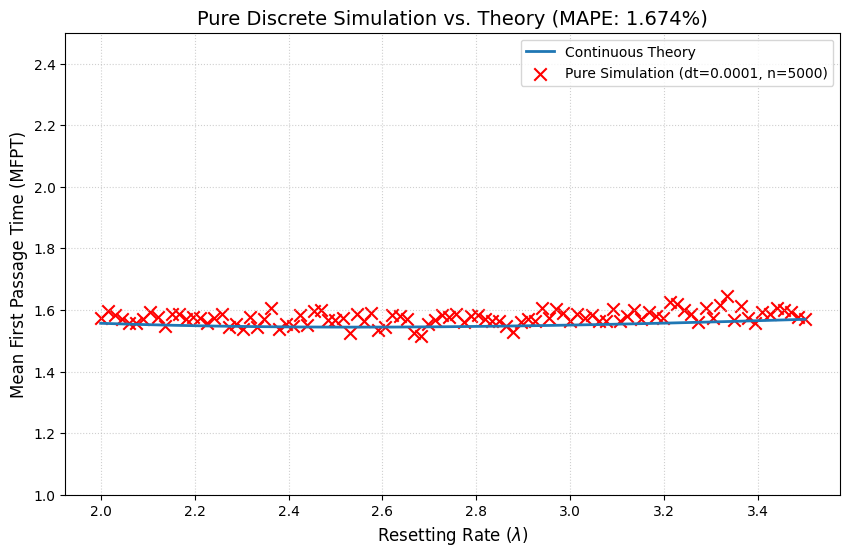

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# --- 1. Set System Parameters ---
D = 1.0
L = 1.0
dt = 1e-4      # Lowered dt to minimize boundary overshoot bias
num_trials = 5000   # Massively increased trials to crush statistical noise

@njit
def simulate_mfpt_pure(lam, D, L, dt, trials):
    """
    Pure numerical MFPT without boundary corrections.
    """
    if lam <= 0: 
        return np.nan
    
    total_fpt = 0.0
    sqrt_2Ddt = np.sqrt(2 * D * dt)
    
    # Exact discrete probability of a reset occurring within dt
    p_reset = 1.0 - np.exp(-lam * dt) 
    
    for _ in range(trials):
        x = 0.0
        t = 0.0
        while x < L:
            # 1. Stochastic Resetting
            if np.random.random() < p_reset:
                x = 0.0
            else:
                # 2. Diffusion step
                x += np.random.normal(0.0, 1.0) * sqrt_2Ddt
            
            t += dt
            
            # Safety break
            if t > 500: 
                break
        total_fpt += t
        
    return total_fpt / trials

# --- 2. Generate Comparison Data ---
sim_lambda_vals = np.linspace(2.0, 3.5, 100) # Wąski zakres, dużo punktów
total_points = len(sim_lambda_vals)
print(f"Rozpoczynam symulację dla {total_points} punktów. Proszę czekać...")

# Pusta tablica na wyniki
sim_results = np.zeros(total_points)

# Pętla z wskaźnikiem postępu
for i, l in enumerate(sim_lambda_vals):
    sim_results[i] = simulate_mfpt_pure(l, D, L, dt, num_trials)
    
    # Obliczanie i wyświetlanie procentu w tej samej linijce
    procent = ((i + 1) / total_points) * 100
    print(f"\rUkończono: {procent:.0f}% ({i + 1}/{total_points} punktów)", end="", flush=True)

print("\nSymulacja zakończona!") # Nowa linia po zakończeniu odliczania

# Calculate exact theoretical values at the same lambda points
theory_at_sim = (1 / sim_lambda_vals) * (np.exp(np.sqrt(sim_lambda_vals / D) * L) - 1)

# --- 3. Calculate Error Metrics ---
mape = np.mean(np.abs((theory_at_sim - sim_results) / theory_at_sim)) * 100
rmse = np.sqrt(np.mean((theory_at_sim - sim_results)**2))

print("-" * 30)
print(f"SIMULATION QUALITY METRICS")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.6f}")
print("-" * 30)

# --- 4. Plotting ---
plt.figure(figsize=(10, 6))
lam_theory_fine = np.linspace(2.0, 3.5, 500)
mfpt_theory_fine = (1 / lam_theory_fine) * (np.exp(np.sqrt(lam_theory_fine / D) * L) - 1)

plt.plot(lam_theory_fine, mfpt_theory_fine, label='Continuous Theory', color='#1f77b4', lw=2)
plt.scatter(sim_lambda_vals, sim_results, color='red', marker='x', s=80, 
            label=f'Pure Simulation (dt={dt}, n={num_trials})')

plt.title(f'Pure Discrete Simulation vs. Theory (MAPE: {mape:.3f}%)', fontsize=14)
plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)
plt.ylabel('Mean First Passage Time (MFPT)', fontsize=12)

plt.ylim(1.0, 2.5) 

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# --- Save Plot ---
# Tworzenie folderu (jeśli nie istnieje) i zapis wykresu
os.makedirs('plots', exist_ok=True)
plot_path = os.path.join('plots', 'simulation_vs_theory.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot successfully saved to: {plot_path}")

plt.show()

In [31]:
# --- 6. Optimal Values Comparison ---
# Find empirical minimum
min_sim_idx = np.argmin(sim_results)
optimal_lambda_sim = sim_lambda_vals[min_sim_idx]
min_mfpt_sim = sim_results[min_sim_idx]

# Find theoretical minimum (using the fine-grained array)
min_theory_idx = np.argmin(mfpt_theory_fine)
optimal_lambda_theory = lam_theory_fine[min_theory_idx]
min_mfpt_theory = mfpt_theory_fine[min_theory_idx]

print("-" * 40)
print("OPTIMAL RESETTING RATE & MINIMUM MFPT")
print(f"Theoretical Lambda*: {optimal_lambda_theory:.4f} | Minimum MFPT: {min_mfpt_theory:.4f}")
print(f"Empirical Lambda* : {optimal_lambda_sim:.4f} | Minimum MFPT: {min_mfpt_sim:.4f}")
print("-" * 40)

----------------------------------------
OPTIMAL RESETTING RATE & MINIMUM MFPT
Theoretical Lambda*: 2.5411 | Minimum MFPT: 1.5441
Empirical Lambda* : 2.6818 | Minimum MFPT: 1.5162
----------------------------------------


<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bartik\AppData\Local\Temp\ipykernel_22028\2784095593.py:22: SyntaxWarning: invalid escape sequence '\m'
  axs[0].plot(x, p, 'k', linewidth=2, label=f'Normal fit\n$\mu$={mu:.4f}\n$\sigma$={std:.4f}')
C:\Users\bartik\AppData\Local\Temp\ipykernel_22028\2784095593.py:22: SyntaxWarning: invalid escape sequence '\s'
  axs[0].plot(x, p, 'k', linewidth=2, label=f'Normal fit\n$\mu$={mu:.4f}\n$\sigma$={std:.4f}')


Plot successfully saved to: plots\residual_analysis.png


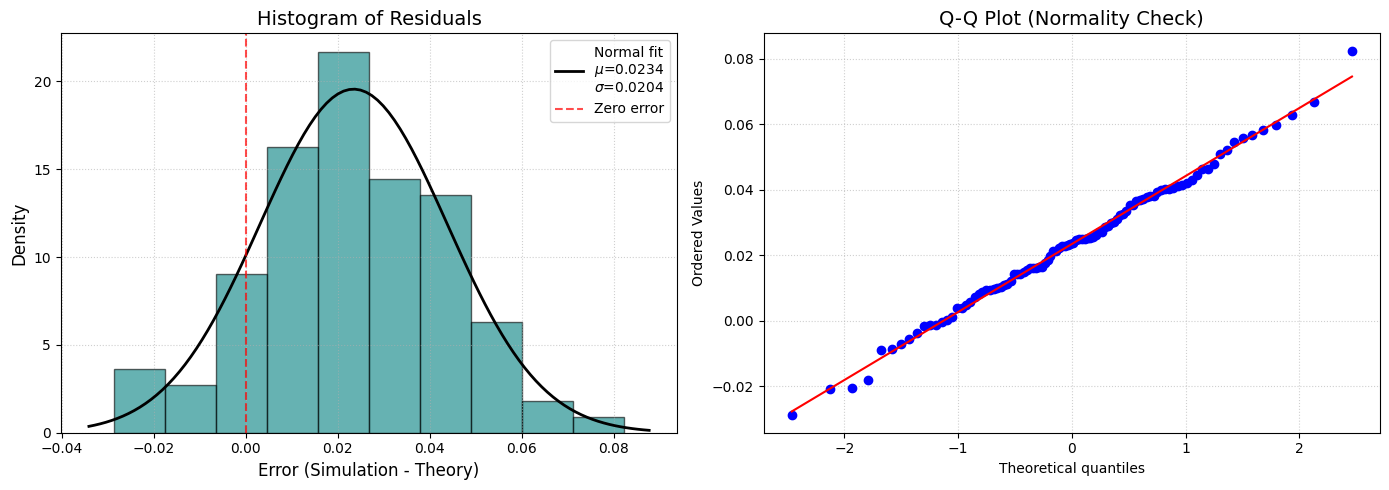

----------------------------------------
SHAPIRO-WILK NORMALITY TEST
Test Statistic: 0.9963
p-value: 0.9957
----------------------------------------
CONCLUSION: Fail to reject the null hypothesis.
The distribution of residuals LOOKS normal (differences are statistical noise).


In [32]:
# --- 5. Residual Analysis (Errors) ---
import os
import scipy.stats as stats

# Create 'plots' directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

# Calculate residuals (difference between simulation and theory)
residuals = sim_results - theory_at_sim

# Set up figure for 2 subplots side-by-side
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Residuals Histogram with Gaussian Curve ---
axs[0].hist(residuals, bins='auto', density=True, alpha=0.6, color='teal', edgecolor='black')

# Fit normal distribution to our data
mu, std = stats.norm.fit(residuals)
xmin, xmax = axs[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axs[0].plot(x, p, 'k', linewidth=2, label=f'Normal fit\n$\mu$={mu:.4f}\n$\sigma$={std:.4f}')

axs[0].set_title('Histogram of Residuals', fontsize=14)
axs[0].set_xlabel('Error (Simulation - Theory)', fontsize=12)
axs[0].set_ylabel('Density', fontsize=12)
axs[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero error')
axs[0].legend()
axs[0].grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Q-Q Plot ---
# If points align along the red line, the distribution is normal
stats.probplot(residuals, dist="norm", plot=axs[1])
axs[1].set_title('Q-Q Plot (Normality Check)', fontsize=14)
axs[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# --- Save Plot ---
# Save the figure BEFORE calling plt.show()
plot_path = os.path.join('plots', 'residual_analysis.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot successfully saved to: {plot_path}")

# Show the plot in the notebook
plt.show()

# --- Shapiro-Wilk Statistical Test ---
stat, p_value = stats.shapiro(residuals)

print("-" * 40)
print("SHAPIRO-WILK NORMALITY TEST")
print(f"Test Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")
print("-" * 40)

# Result interpretation (assuming standard significance level of 0.05)
if p_value > 0.05:
    print("CONCLUSION: Fail to reject the null hypothesis.")
    print("The distribution of residuals LOOKS normal (differences are statistical noise).")
else:
    print("CONCLUSION: Reject the null hypothesis.")
    print("The distribution of residuals is PROBABLY NOT normal (possible systematic errors/bias).")

Starting simulation for 1000000 trials per alpha...
Simulating for alpha = 0.5...
Simulating for alpha = 1.5...
Simulating for alpha = 2.5...
Simulation finished!
Wykres zapisany: plots/pareto_convergence.png


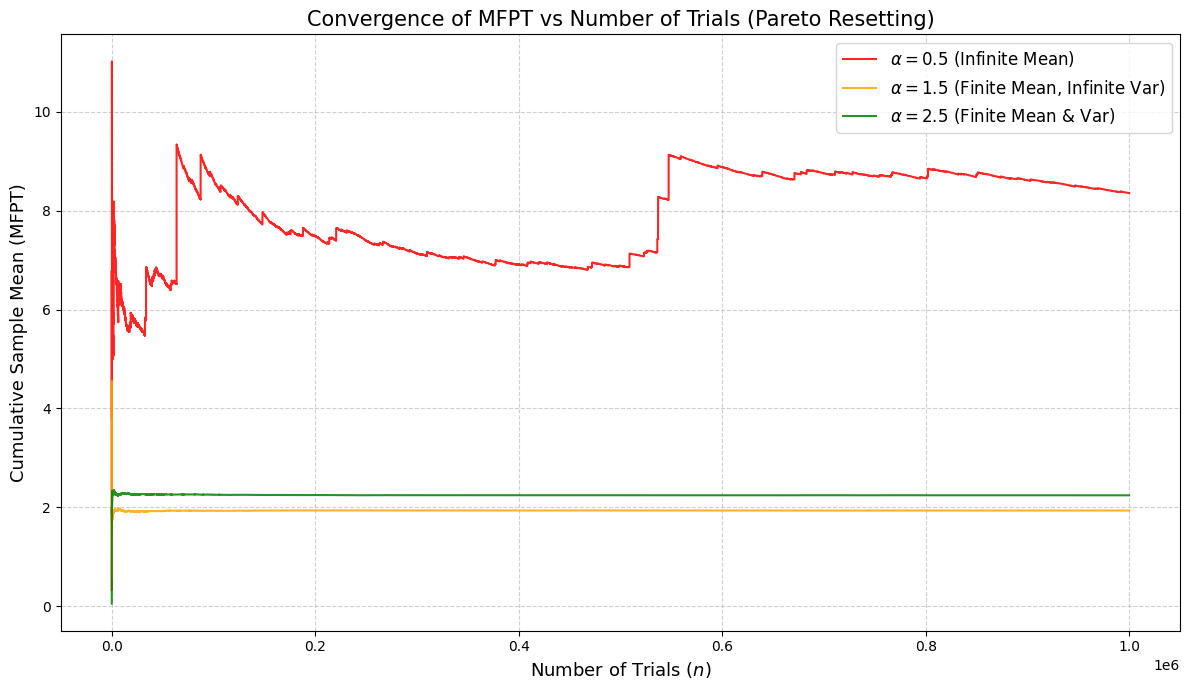

In [33]:
# --- Extension: Convergence of MFPT under Pareto Resetting ---

import numpy as np
import matplotlib.pyplot as plt
from numba import njit

@njit
def simulate_fpt_array_pareto(alpha, xm, D, L, dt, trials, max_time=100000):
    """
    Simulates FPTs with Pareto resetting and returns an array of INDIVIDUAL passage times.
    We use a large max_time because alpha=0.5 can produce massive time gaps.
    """
    fpts = np.zeros(trials)
    sqrt_2Ddt = np.sqrt(2 * D * dt)
    
    for i in range(trials):
        x = 0.0
        t = 0.0
        
        t_next_reset = xm * (np.random.pareto(alpha) + 1.0)
        t_since_reset = 0.0
        
        while x < L:
            # Diffusion step
            x += np.random.normal(0.0, 1.0) * sqrt_2Ddt
            t += dt
            t_since_reset += dt
            
            # Reset condition
            if t_since_reset >= t_next_reset:
                x = 0.0
                t_since_reset = 0.0
                t_next_reset = xm * (np.random.pareto(alpha) + 1.0)
                
            # Fuse to prevent literal infinite loops in the alpha=0.5 case
            if t > max_time:
                break
                
        fpts[i] = t
        
    return fpts

# --- Simulation Parameters ---
D = 1.0
L = 1.0
dt = 0.001
trials = 1000000  # Number of trials to observe convergence behavior
xm = 0.1
max_time = 500000 # Increased to capture the heavy tails properly

alphas = [0.5, 1.5, 2.5]
colors = ['red', 'orange', 'green']
labels = [
    r'$\alpha = 0.5$ (Infinite Mean)', 
    r'$\alpha = 1.5$ (Finite Mean, Infinite Var)', 
    r'$\alpha = 2.5$ (Finite Mean & Var)'
]

plt.figure(figsize=(12, 7))

print(f"Starting simulation for {trials} trials per alpha...")

for alpha, color, label in zip(alphas, colors, labels):
    print(f"Simulating for alpha = {alpha}...")
    
    # 1. Get the array of individual first passage times
    fpts = simulate_fpt_array_pareto(alpha, xm, D, L, dt, trials, max_time)
    
    # 2. Calculate the cumulative moving average (Sample Mean as n increases)
    # np.cumsum(fpts) gives the running sum, dividing by the index gives the running mean
    n_array = np.arange(1, trials + 1)
    cumulative_mfpt = np.cumsum(fpts) / n_array
    
    # 3. Plot the cumulative mean
    plt.plot(n_array, cumulative_mfpt, color=color, lw=1.5, label=label, alpha=0.85)

print("Simulation finished!")

# --- Plot Formatting ---
plt.title('Convergence of MFPT vs Number of Trials (Pareto Resetting)', fontsize=15)
plt.xlabel('Number of Trials ($n$)', fontsize=13)
plt.ylabel('Cumulative Sample Mean (MFPT)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

os.makedirs('plots', exist_ok=True)
plt.savefig('plots/pareto_convergence.png', dpi=300, bbox_inches='tight')
print("Wykres zapisany: plots/pareto_convergence.png")

plt.show()